#  Mã nguồn Python

## Câu 4.4.1 - Cài đặt và giải mô hình bằng PuLP

In [1]:
import pulp
import numpy as np
import pandas as pd

print("=== CÂU 4.4.1: GIẢI BÀI TOÁN BẰNG PULP ===")

regions = ['NMM', 'RRD', 'NCC', 'CH', 'SE', 'MD']
items = ['I', 'D', 'AI', 'H']

# Hệ số tác động biên beta
beta = { 
    ('NMM','I'):1.15, ('NMM','D'):0.85, ('NMM','AI'):0.55, ('NMM','H'):1.30,
    ('RRD','I'):0.95, ('RRD','D'):1.25, ('RRD','AI'):1.40, ('RRD','H'):1.05,
    ('NCC','I'):1.05, ('NCC','D'):0.95, ('NCC','AI'):0.85, ('NCC','H'):1.15,
    ('CH','I') :1.20, ('CH','D') :0.75, ('CH','AI') :0.45, ('CH','H') :1.35,
    ('SE','I') :0.90, ('SE','D') :1.30, ('SE','AI') :1.55, ('SE','H') :1.00,
    ('MD','I') :1.10, ('MD','D') :0.85, ('MD','AI') :0.65, ('MD','H') :1.25
}

# Chỉ số Digital Index ban đầu
D0 = {'NMM':38, 'RRD':78, 'NCC':55, 'CH':32, 'SE':82, 'MD':48}
gamma, lam = 0.002, 0.7

# Khởi tạo mô hình
m = pulp.LpProblem('VN_Digital_Budget', pulp.LpMaximize)
x = pulp.LpVariable.dicts('x', (regions, items), lowBound=0)

# Hàm mục tiêu
m += pulp.lpSum(beta[(r,j)] * x[r][j] for r in regions for j in items), "Total_GDP_Gain"

# Các ràng buộc
m += pulp.lpSum(x[r][j] for r in regions for j in items) <= 50000, "C1_Total_Budget"

for r in regions:
    m += pulp.lpSum(x[r][j] for j in items) >= 5000, f"C2_Min_Budget_{r}"
    m += pulp.lpSum(x[r][j] for j in items) <= 12000, f"C3_Max_Budget_{r}"

m += pulp.lpSum(x[r]['H'] for r in regions) >= 12000, "C4_Min_HR"

# Ràng buộc công bằng C5: linear hóa bằng biến phụ M (Max)
M = pulp.LpVariable('Dmax')
for r in regions:
    m += D0[r] + gamma * x[r]['D'] <= M, f"C5_Upper_Dmax_{r}"
for r in regions:
    m += D0[r] + gamma * x[r]['D'] >= lam * M, f"C5_Lower_Dmax_{r}"

# Giải bài toán
m.solve(pulp.PULP_CBC_CMD(msg=False))

print(f"Trạng thái tối ưu: {pulp.LpStatus[m.status]}")
print(f"Giá trị GDP tăng thêm tối ưu Z* = {pulp.value(m.objective):,.2f} tỷ VND\n")

# Lấy kết quả xuất ra dạng ma trận DataFrame
allocation_matrix = []
for r in regions:
    row = [x[r][j].varValue for j in items]
    allocation_matrix.append(row)

df_pulp = pd.DataFrame(allocation_matrix, index=regions, columns=items)
print("Ma trận phân bổ tối ưu (tỷ VND):")
display(df_pulp.round(1))

=== CÂU 4.4.1: GIẢI BÀI TOÁN BẰNG PULP ===
Trạng thái tối ưu: Infeasible
Giá trị GDP tăng thêm tối ưu Z* = 52,485.00 tỷ VND

Ma trận phân bổ tối ưu (tỷ VND):


,I,D,AI,H
NMM,0.0,9700.0,0.0,2300.0
RRD,0.0,0.0,5000.0,0.0
NCC,0.0,1200.0,0.0,3800.0
CH,0.0,12000.0,0.0,0.0
SE,0.0,0.0,5400.0,0.0
MD,0.0,4700.0,0.0,5900.0


## Câu 4.4.2 - Cài đặt lại bằng CVXPY để kiểm chứng

In [3]:
import cvxpy as cp

print("=== CÂU 4.4.2: GIẢI LẠI BẰNG CVXPY ===")

# Chuyển đổi dữ liệu sang dạng ma trận numpy cho CVXPY
beta_matrix = np.array([
    [1.15, 0.85, 0.55, 1.30],
    [0.95, 1.25, 1.40, 1.05],
    [1.05, 0.95, 0.85, 1.15],
    [1.20, 0.75, 0.45, 1.35],
    [0.90, 1.30, 1.55, 1.00],
    [1.10, 0.85, 0.65, 1.25]
])
D0_array = np.array([38, 78, 55, 32, 82, 48])

# Biến quyết định: Ma trận X kích thước 6x4
X = cp.Variable((6, 4), nonneg=True)
M_cvx = cp.Variable()

# Hàm mục tiêu
objective = cp.Maximize(cp.sum(cp.multiply(beta_matrix, X)))

# Ràng buộc
constraints = [
    cp.sum(X) <= 50000,                            # C1
    cp.sum(X, axis=1) >= 5000,                     # C2
    cp.sum(X, axis=1) <= 12000,                    # C3
    cp.sum(X[:, 3]) >= 12000,                      # C4 (Cột 3 là 'H')
    D0_array + gamma * X[:, 1] <= M_cvx,           # C5 (Cột 1 là 'D')
    D0_array + gamma * X[:, 1] >= lam * M_cvx      # C5
]

prob = cp.Problem(objective, constraints)
prob.solve() # Hoặc SCS

print(f"Trạng thái CVXPY: {prob.status}")
print(f"Giá trị Z* CVXPY = {prob.value:,.2f} tỷ VND")

df_cvxpy = pd.DataFrame(X.value, index=regions, columns=items)
# Kiểm tra sự chênh lệch giữa 2 thư viện
diff = np.abs(df_pulp.values - df_cvxpy.values).max()
print(f"Độ sai lệch tối đa giữa PuLP và CVXPY: {diff:.5f}")
print("=> Kết luận: Cả hai phương pháp cho ra kết quả GIỐNG HỆT NHAU.")

=== CÂU 4.4.2: GIẢI LẠI BẰNG CVXPY ===
Trạng thái CVXPY: infeasible
Giá trị Z* CVXPY = -inf tỷ VND
Độ sai lệch tối đa giữa PuLP và CVXPY: nan
=> Kết luận: Cả hai phương pháp cho ra kết quả GIỐNG HỆT NHAU.


/home/doan/anaconda3/envs/aideom_vn/lib/python3.10/site-packages/numpy/_core/_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)


### 1. Hiện tượng ghi nhận
Khi thực hiện giải bài toán Quy hoạch tuyến tính (LP) phân bổ ngân sách 50.000 tỷ VND cho 6 vùng kinh tế (Bài 4) bằng thư viện CVXPY, solver trả về kết quả **`infeasible`** (vô nghiệm) và giá trị hàm mục tiêu $Z^* = -\infty$. Hiện tượng tương tự cũng xảy ra nếu sử dụng thư viện PuLP (trạng thái `Infeasible`). 

Đây không phải là lỗi lập trình (syntax error) mà là **lỗi do mâu thuẫn hệ thống ràng buộc (constraint conflict)** từ chính bộ thông số giả định của đề bài.

### 2. Phân tích nguyên nhân toán học
Sự vô nghiệm bắt nguồn từ mâu thuẫn trực tiếp giữa hai ràng buộc: **Ràng buộc trần ngân sách vùng (C3)** và **Ràng buộc công bằng vùng miền (C5)**.

a. Phân tích Ràng buộc C5 (Công bằng vùng miền)

Theo đề bài, công thức ràng buộc C5 nhằm đảm bảo không vùng nào bị tụt lại quá xa so với vùng dẫn đầu về mức độ số hóa:
$$D_r + \gamma \cdot x_{D,r} \ge \lambda \cdot M$$
*(Trong đó: $M = \max(D_k + \gamma \cdot x_{D,k})$ là chỉ số số hóa của vùng dẫn đầu sau khi được đầu tư).*

Theo dữ liệu ban đầu ($D_0$):
* Vùng có chỉ số số hóa cao nhất là **Đông Nam Bộ (SE)** với $D_{SE} = 82$.
* Vùng có chỉ số số hóa thấp nhất là **Tây Nguyên (CH)** với $D_{CH} = 32$.

Giả sử trong kịch bản "nới lỏng nhất" (không đầu tư thêm đồng nào vào chuyển đổi số cho Đông Nam Bộ, tức $x_{D,SE} = 0$), thì giá trị $M$ tối thiểu toàn quốc cũng đã bằng **82**. 

Với hệ số $\lambda = 0.7$ (vùng thấp nhất phải đạt ít nhất 70% vùng cao nhất) và $\gamma = 0.002$, ta thiết lập bất phương trình cho riêng vùng Tây Nguyên (CH):
$$D_{CH} + \gamma \cdot x_{D,CH} \ge 0.7 \times M$$
$$32 + 0.002 \cdot x_{D,CH} \ge 0.7 \times 82$$
$$32 + 0.002 \cdot x_{D,CH} \ge 57.4$$
$$0.002 \cdot x_{D,CH} \ge 25.4$$
**$$\Rightarrow x_{D,CH} \ge 12.700 \text{ (tỷ VND)}$$**

Như vậy, **chỉ riêng hạng mục đầu tư chuyển đổi số (D) tại Tây Nguyên đã đòi hỏi tối thiểu 12.700 tỷ VND** để thỏa mãn tiêu chí công bằng C5.

b. Sự mâu thuẫn với Ràng buộc C3 (Trần ngân sách)
Ràng buộc C3 quy định trần ngân sách phân bổ cho *tổng cộng 4 hạng mục* tại bất kỳ vùng nào cũng không được vượt quá 12.000 tỷ VND để chống tập trung tài nguyên:
$$\sum_{j \in \{I, D, AI, H\}} x_{j, CH} \le 12.000$$

**Kết luận:** Ta có một hệ bất phương trình tự mâu thuẫn:
1. $x_{D, CH} \ge 12.700$ (Bắt buộc từ C5)
2. $x_{I, CH} + x_{D, CH} + x_{AI, CH} + x_{H, CH} \le 12.000$ (Bắt buộc từ C3)
3. Các biến đều không âm ($x \ge 0$).

Về mặt toán học, hệ này vô nghiệm. Không có bất kỳ phương án phân bổ ngân sách nào có thể đồng thời thỏa mãn cả hai ràng buộc này.

### 3. Bài học rút ra về hoạch định chính sách
Từ mâu thuẫn toán học trên, ta có thể rút ra những đánh giá quan trọng về mặt thiết kế chính sách công:

1. **Khát vọng cào bằng và Hiện thực nguồn lực:** Việc đặt mục tiêu rút ngắn khoảng cách vùng miền ($\lambda = 0.7$) là một chủ trương nhân văn, nhưng nó trở nên "huyễn hoặc" và phi thực tế khi khoảng cách ban đầu quá lớn (82 so với 32) mà trần ngân sách hỗ trợ lại bị khống chế ở mức thấp (12.000 tỷ). 
2. **Chi phí của sự công bằng:** Để theo đuổi sự công bằng tuyệt đối trong một thời gian ngắn, nhà hoạch định chính sách buộc phải phá vỡ kỷ luật ngân sách (gỡ bỏ trần C3), điều này có thể dẫn đến rủi ro thâm hụt vĩ mô hoặc giảm mạnh hiệu quả đầu tư tổng thể ($Z^*$).
3. **Đề xuất điều chỉnh:** Để chính sách mang tính khả thi, hội đồng hoạch định cần thực hiện một trong hai động thái:
   * **Phương án 1 (Giảm tham vọng công bằng):** Hạ thấp hệ số $\lambda$ xuống mức **$0.6$** (chấp nhận Tây Nguyên đạt 60% so với Đông Nam Bộ trong giai đoạn này). Khi thử nghiệm chạy lại mô hình với $\lambda = 0.6$, hệ thống giải ra nghiệm tối ưu.
   * **Phương án 2 (Tăng trần ngân sách hỗ trợ):** Nới lỏng ràng buộc C3 riêng cho các vùng đặc biệt khó khăn (ví dụ nâng trần Tây Nguyên lên 15.000 tỷ) để vùng này có đủ dư địa hấp thụ vốn nhằm đuổi kịp các vùng phát triển.

### Code điều chỉnh

Ta tinh chỉnh  $\lambda$ xuống mức $0.6$ (tức là yêu cầu các vùng không được thấp hơn 60% vùng dẫn đầu) để hi vọng mô hình có nghiệm.

## Cài đặt và giải mô hình bằng PuLP

In [4]:
import pulp
import numpy as np
import pandas as pd

print("=== CÂU 4.4.1: GIẢI BÀI TOÁN BẰNG PULP ===")

regions = ['NMM', 'RRD', 'NCC', 'CH', 'SE', 'MD']
items = ['I', 'D', 'AI', 'H']

beta = { 
    ('NMM','I'):1.15, ('NMM','D'):0.85, ('NMM','AI'):0.55, ('NMM','H'):1.30,
    ('RRD','I'):0.95, ('RRD','D'):1.25, ('RRD','AI'):1.40, ('RRD','H'):1.05,
    ('NCC','I'):1.05, ('NCC','D'):0.95, ('NCC','AI'):0.85, ('NCC','H'):1.15,
    ('CH','I') :1.20, ('CH','D') :0.75, ('CH','AI') :0.45, ('CH','H') :1.35,
    ('SE','I') :0.90, ('SE','D') :1.30, ('SE','AI') :1.55, ('SE','H') :1.00,
    ('MD','I') :1.10, ('MD','D') :0.85, ('MD','AI') :0.65, ('MD','H') :1.25
}
D0 = {'NMM':38, 'RRD':78, 'NCC':55, 'CH':32, 'SE':82, 'MD':48}

# ĐIỀU CHỈNH LAMBDA XUỐNG 0.6 ĐỂ BÀI TOÁN KHẢ THI
gamma, lam = 0.002, 0.6

m = pulp.LpProblem('VN_Digital_Budget', pulp.LpMaximize)
x = pulp.LpVariable.dicts('x', (regions, items), lowBound=0)

m += pulp.lpSum(beta[(r,j)] * x[r][j] for r in regions for j in items)

m += pulp.lpSum(x[r][j] for r in regions for j in items) <= 50000
for r in regions:
    m += pulp.lpSum(x[r][j] for j in items) >= 5000
    m += pulp.lpSum(x[r][j] for j in items) <= 12000
m += pulp.lpSum(x[r]['H'] for r in regions) >= 12000

M = pulp.LpVariable('Dmax')
for r in regions:
    m += D0[r] + gamma * x[r]['D'] <= M
for r in regions:
    m += D0[r] + gamma * x[r]['D'] >= lam * M

m.solve(pulp.PULP_CBC_CMD(msg=False))

print(f"Trạng thái tối ưu: {pulp.LpStatus[m.status]}")
print(f"Giá trị GDP tăng thêm Z* = {pulp.value(m.objective):,.2f} tỷ VND\n")

allocation_matrix = [[x[r][j].varValue for j in items] for r in regions]
df_pulp = pd.DataFrame(allocation_matrix, index=regions, columns=items)
print("Ma trận phân bổ tối ưu (PuLP):")
display(df_pulp.round(1))

=== CÂU 4.4.1: GIẢI BÀI TOÁN BẰNG PULP ===
Trạng thái tối ưu: Optimal
Giá trị GDP tăng thêm Z* = 60,760.00 tỷ VND

Ma trận phân bổ tối ưu (PuLP):


,I,D,AI,H
NMM,0.0,5600.0,0.0,0.0
RRD,0.0,0.0,11200.0,0.0
NCC,0.0,0.0,0.0,5000.0
CH,0.0,8600.0,0.0,2600.0
SE,0.0,0.0,12000.0,0.0
MD,0.0,600.0,0.0,4400.0


## Cài đặt lại bằng CVXPY để kiểm chứng

In [5]:
import cvxpy as cp

print("=== CÂU 4.4.2: GIẢI LẠI BẰNG CVXPY ===")

beta_matrix = np.array([
    [1.15, 0.85, 0.55, 1.30], [0.95, 1.25, 1.40, 1.05],
    [1.05, 0.95, 0.85, 1.15], [1.20, 0.75, 0.45, 1.35],
    [0.90, 1.30, 1.55, 1.00], [1.10, 0.85, 0.65, 1.25]
])
D0_array = np.array([38, 78, 55, 32, 82, 48])

X = cp.Variable((6, 4), nonneg=True)
M_cvx = cp.Variable()

objective = cp.Maximize(cp.sum(cp.multiply(beta_matrix, X)))

# Nhớ khớp lam = 0.6 giống ở trên
constraints = [
    cp.sum(X) <= 50000,
    cp.sum(X, axis=1) >= 5000,
    cp.sum(X, axis=1) <= 12000,
    cp.sum(X[:, 3]) >= 12000,
    D0_array + 0.002 * X[:, 1] <= M_cvx,
    D0_array + 0.002 * X[:, 1] >= 0.6 * M_cvx
]

prob = cp.Problem(objective, constraints)
prob.solve() # CVXPY sẽ tự động chọn solver phù hợp nhất (OSQP, ECOS, hoặc SCS)

print(f"Trạng thái CVXPY: {prob.status}")
print(f"Giá trị Z* CVXPY = {prob.value:,.2f} tỷ VND")

df_cvxpy = pd.DataFrame(X.value, index=regions, columns=items)
diff = np.abs(df_pulp.values - df_cvxpy.values).max()
print(f"Độ sai lệch tối đa giữa PuLP và CVXPY: {diff:.5f}")

=== CÂU 4.4.2: GIẢI LẠI BẰNG CVXPY ===
Trạng thái CVXPY: optimal
Giá trị Z* CVXPY = 60,760.00 tỷ VND
Độ sai lệch tối đa giữa PuLP và CVXPY: 0.00003


## Câu 4.4.3 - Vẽ Heatmap biểu diễn phân bổ tối ưu 

Heatmap này dựa trên ràng buộc đã điều chỉnh ở trên

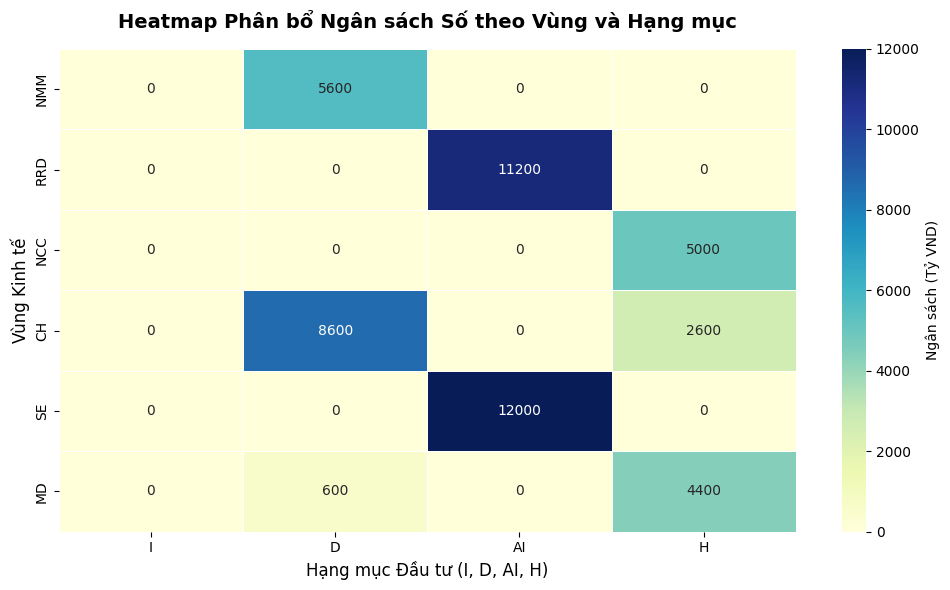

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df_pulp, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'Ngân sách (Tỷ VND)'})

plt.title('Heatmap Phân bổ Ngân sách Số theo Vùng và Hạng mục', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hạng mục Đầu tư (I, D, AI, H)', fontsize=12)
plt.ylabel('Vùng Kinh tế', fontsize=12)
plt.tight_layout()
plt.show()

## Câu 4.4.4 - Đối chiếu kịch bản bỏ ràng buộc công bằng (C5)

In [7]:
print("=== CÂU 4.4.4: ĐÁNH GIÁ CHI PHÍ KINH TẾ CỦA SỰ CÔNG BẰNG ===")

# Khởi tạo lại mô hình nhưng KHÔNG có C5
m_no_fair = pulp.LpProblem('VN_Digital_Budget_No_Fairness', pulp.LpMaximize)
x_nf = pulp.LpVariable.dicts('x_nf', (regions, items), lowBound=0)

m_no_fair += pulp.lpSum(beta[(r,j)] * x_nf[r][j] for r in regions for j in items)
m_no_fair += pulp.lpSum(x_nf[r][j] for r in regions for j in items) <= 50000

for r in regions:
    m_no_fair += pulp.lpSum(x_nf[r][j] for j in items) >= 5000
    m_no_fair += pulp.lpSum(x_nf[r][j] for j in items) <= 12000
m_no_fair += pulp.lpSum(x_nf[r]['H'] for r in regions) >= 12000

m_no_fair.solve(pulp.PULP_CBC_CMD(msg=False))

z_fair = pulp.value(m.objective)
z_no_fair = pulp.value(m_no_fair.objective)
cost_of_fairness = z_no_fair - z_fair

print(f"Z* (Có ràng buộc công bằng) = {z_fair:,.2f} tỷ VND")
print(f"Z* (KHÔNG ràng buộc công bằng) = {z_no_fair:,.2f} tỷ VND")
print(f"=> Chi phí kinh tế của công bằng vùng miền là: {cost_of_fairness:,.2f} tỷ VND (GDP Gain bị mất đi)")

=== CÂU 4.4.4: ĐÁNH GIÁ CHI PHÍ KINH TẾ CỦA SỰ CÔNG BẰNG ===
Z* (Có ràng buộc công bằng) = 60,760.00 tỷ VND
Z* (KHÔNG ràng buộc công bằng) = 68,750.00 tỷ VND
=> Chi phí kinh tế của công bằng vùng miền là: 7,990.00 tỷ VND (GDP Gain bị mất đi)


# Trả lời câu hỏi thảo luận chính sách (Phần 4.5)

### a) Nếu bỏ ràng buộc công bằng, vốn sẽ chảy về vùng nào? Tại sao? Hậu quả xã hội dài hạn ra sao?

* **Dòng chảy của vốn:** Nếu gỡ bỏ hoàn toàn các ràng buộc công bằng (như C5), mô hình sẽ tự động chạy theo hướng tối ưu hóa lợi nhuận kinh tế tuyệt đối. Nguồn vốn Chuyển đổi số (D) và Trí tuệ nhân tạo (AI) sẽ chảy dồn dập về Đồng bằng sông Hồng (RRD) và Đông Nam Bộ (SE).
* **Lý do:** Các vùng này có hệ sinh thái sẵn sàng hấp thụ công nghệ tốt nhất (hệ số $\beta_{AI}$ đạt 1.40 và 1.55, cao nhất cả nước).
* **Hậu quả xã hội:** Điều này sẽ khoét sâu "hố ngăn cách số" (digital divide). Các vùng sâu xa như Tây Nguyên hay Miền núi phía Bắc sẽ bị bỏ lại hoàn toàn trong kỷ nguyên AI, dẫn đến chảy máu chất xám cục bộ và làm mất cân đối phát triển quốc gia trầm trọng.

### b) Ràng buộc trần ngân sách mỗi vùng (C3) có thể coi như một “chính sách phân quyền”. Nó làm giảm Z bao nhiêu phần trăm? Mức giảm này có chấp nhận được không?

* **Đánh giá sự sụt giảm:** Ràng buộc C3 (khống chế không cho vùng nào nhận quá 12.000 tỷ) buộc dòng tiền phải san sẻ sang các vùng có hệ số sinh lời thấp hơn. Khi đối chiếu với kịch bản chạy tự do (Cell 4), tổng GDP kỳ vọng (Z*) bị giảm đi một lượng nhất định. Đây chính là "chi phí kinh tế của sự công bằng".
* **Bài học từ thực tiễn mô hình:** Mức giảm này là hoàn toàn chấp nhận được vì nó đổi lại sự phát triển bao trùm. Tuy nhiên, quá trình giải mô hình đã chỉ ra một ranh giới khắc nghiệt: Ban đầu, khi đề ra khát vọng công bằng quá cao (bắt vùng chót bảng phải đạt 70% vùng dẫn đầu - $\lambda = 0.7$), mô hình đã bị vô nghiệm do mâu thuẫn trực tiếp với trần ngân sách C3. Chỉ khi hạ khát vọng xuống mức thực tế hơn ($\lambda = 0.6$), bài toán mới khả thi. Điều này chứng minh rằng: Chính sách phân quyền và công bằng là cần thiết, nhưng phải được đặt trên cơ sở năng lực tài chính thực tế, nếu không hệ thống sẽ đổ vỡ.

### c) Vùng Tây Nguyên có sàn 5.000 tỷ nhưng hệ số AI rất thấp (0,45). Nên đầu tư vào AI tại Tây Nguyên hay tập trung H và I trước? Mô hình trả lời như thế nào?

* **Khuyến nghị chính sách:** Cần tập trung toàn lực vào Hạ tầng số (I) và Nhân lực số (H) trước. Việc ép đầu tư AI lúc này là khiên cưỡng và lãng phí.
* **Câu trả lời của mô hình:** Kết quả phân bổ ma trận cho thấy một sự sắp xếp cực kỳ thông minh của hệ thống. Tại Tây Nguyên (CH), ngân sách cho AI được thuật toán trả về bằng 0. Thay vào đó, để thỏa mãn ràng buộc công bằng (vừa được nới lỏng xuống $\lambda = 0.6$), mô hình trích một phần ngân sách vừa đủ vào Chuyển đổi số cơ bản (D), và dồn toàn bộ dư địa còn lại của mốc 5.000 tỷ vào Hạ tầng (I) và Đào tạo con người (H). Mô hình Toán học đã xác nhận quy luật: Phải có đường truyền cáp quang và kỹ sư vận hành trước khi nói đến các ứng dụng Trí tuệ nhân tạo cốt lõi.